In [1]:
# EfficientNetV2 Emotion Training 
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

import time
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from torch.cuda.amp import autocast, GradScaler
from torchvision import models

# ============================================================
# CONFIG
# ============================================================

train_dir = '/kaggle/input/datasets/lorddemon/face-emotion-balance-dataset-american-asian/Balanced/Train'
test_dir  = '/kaggle/input/datasets/lorddemon/face-emotion-balance-dataset-american-asian/Balanced/Test'

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50

LR = 4e-4
WEIGHT_DECAY = 1e-4

PATIENCE = 8   # early stopping

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

# ============================================================
# FILTER DATASET TO REMOVE SPECIFIC CLASS
# ============================================================

class FilteredImageFolder(datasets.ImageFolder):

    def __init__(self, root, transform=None, exclude_classes=None):

        super().__init__(root, transform=transform)

        if exclude_classes is None:
            exclude_classes = []

        exclude_classes = set(exclude_classes)

        # keep only allowed samples
        new_samples = []
        new_targets = []

        for path, target in self.samples:

            class_name = self.classes[target]

            if class_name not in exclude_classes:

                new_samples.append((path, target))
                new_targets.append(target)

        self.samples = new_samples
        self.targets = new_targets

        # rebuild class_to_idx without excluded classes
        self.classes = [
            c for c in self.classes if c not in exclude_classes
        ]

        self.class_to_idx = {
            c: i for i, c in enumerate(self.classes)
        }

        # remap targets
        remapped_samples = []
        remapped_targets = []

        for path, target in self.samples:

            class_name = os.path.basename(os.path.dirname(path))

            new_target = self.class_to_idx[class_name]

            remapped_samples.append((path, new_target))
            remapped_targets.append(new_target)

        self.samples = remapped_samples
        self.targets = remapped_targets

# ============================================================
# TRANSFORMS (required for EfficientNetV2 pretrained)
# ============================================================

weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),
    normalize
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

# ============================================================
# DATASETS
# ============================================================

EXCLUDE_CLASSES = ["disgust", "surprise"]

train_dataset = FilteredImageFolder(
    train_dir,
    transform=train_transform,
    exclude_classes=EXCLUDE_CLASSES
)

test_dataset = FilteredImageFolder(
    test_dir,
    transform=test_transform,
    exclude_classes=EXCLUDE_CLASSES
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# MODEL

weights = models.ConvNeXt_Small_Weights.IMAGENET1K_V1

model = models.convnext_small(weights=weights)

# Replace classifier
in_features = model.classifier[-1].in_features

# 2. Rebuild the classifier
model.classifier[-1] = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, num_classes)
)

model = model.to(DEVICE)

FREEZE_EPOCHS = 5

def freeze_backbone(model):
    for param in model.features.parameters():
        param.requires_grad = False

def unfreeze_backbone(model):
    for param in model.features.parameters():
        param.requires_grad = True

# Freeze now
freeze_backbone(model)


# LOSS + OPTIMIZER
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# optional scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# AMP scaler
scaler = GradScaler()

# HISTORY TRACKING
history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}


# EARLY STOPPING
best_acc = 0
best_model = copy.deepcopy(model.state_dict())
patience_counter = 0


# TRAIN FUNCTION
def train_one_epoch():

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        _, preds = outputs.max(1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total

    return epoch_loss, epoch_acc


# TEST FUNCTION
def evaluate():

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            with autocast():

                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total

    return epoch_loss, epoch_acc


# TRAIN LOOP
print("\nStarting Training...\n")

for epoch in range(EPOCHS):

    start = time.time()

    # UNFREEZE AFTER FREEZE_EPOCHS
    if epoch == FREEZE_EPOCHS:

        print("\nUnfreezing backbone...")

        unfreeze_backbone(model)

        optimizer = optim.AdamW(
            model.parameters(),
            lr=LR * 0.1,   # lower LR for finetuning
            weight_decay=WEIGHT_DECAY
        )

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=EPOCHS - FREEZE_EPOCHS
        )

    # ========================================================

    train_loss, train_acc = train_one_epoch()

    test_loss, test_acc = evaluate()

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{EPOCHS}")

    if epoch < FREEZE_EPOCHS:
        print("Mode: FROZEN")
    else:
        print("Mode: FINETUNE")

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")
    print(f"Time: {elapsed:.2f}s")

    # Early stopping
    if test_acc > best_acc:

        best_acc = test_acc
        best_model = copy.deepcopy(model.state_dict())

        torch.save(best_model, "best_efficientnetv2_emotion.pth")

        patience_counter = 0

        print("Best model saved")

    else:

        patience_counter += 1

        print(f"EarlyStop Counter: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:

            print("\n Early stopping triggered")
            break

# load best model
model.load_state_dict(best_model)

print("\nBest Test Accuracy:", best_acc)

torch.save(history, "training_history.pth")

# PLOT HISTORY

plt.figure()

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")

plt.legend()
plt.title("Loss")
plt.show()

plt.figure()

plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["test_acc"], label="Test Acc")

plt.legend()
plt.title("Accuracy")
plt.show()

print("Training Complete.")

# FINAL EVALUATION: CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        with autocast():
            outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))

cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:\n")
print(cm)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

Device: cuda


NameError: name 'os' is not defined

Device: cuda
Classes: ['anger', 'fear', 'happy', 'neutral', 'sad']
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 193MB/s] 



Starting Training...



/tmp/ipykernel_55/1050918930.py:214: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_55/1050918930.py:247: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_55/1050918930.py:286: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/50
Mode: FROZEN
Train Loss: 1.4174 | Train Acc: 0.3909
Test  Loss: 1.2793 | Test  Acc: 0.4974
Time: 36.17s
Best model saved
Epoch 2/50
Mode: FROZEN
Train Loss: 1.2503 | Train Acc: 0.4835
Test  Loss: 1.1762 | Test  Acc: 0.5315
Time: 25.93s
Best model saved
Epoch 3/50
Mode: FROZEN
Train Loss: 1.2006 | Train Acc: 0.5115
Test  Loss: 1.1360 | Test  Acc: 0.5454
Time: 26.33s
Best model saved
Epoch 4/50
Mode: FROZEN
Train Loss: 1.1809 | Train Acc: 0.5182
Test  Loss: 1.1586 | Test  Acc: 0.5216
Time: 27.07s
EarlyStop Counter: 1/8
Epoch 5/50
Mode: FROZEN
Train Loss: 1.1630 | Train Acc: 0.5221
Test  Loss: 1.1298 | Test  Acc: 0.5342
Time: 28.16s
EarlyStop Counter: 2/8

Unfreezing backbone...
Epoch 6/50
Mode: FINETUNE
Train Loss: 0.9690 | Train Acc: 0.6308
Test  Loss: 0.7919 | Test  Acc: 0.7157
Time: 57.15s
Best model saved
Epoch 7/50
Mode: FINETUNE
Train Loss: 0.7749 | Train Acc: 0.7473
Test  Loss: 0.7180 | Test  Acc: 0.7655
Time: 51.89s
Best model saved
Epoch 8/50
Mode: FINETUNE
Train Loss

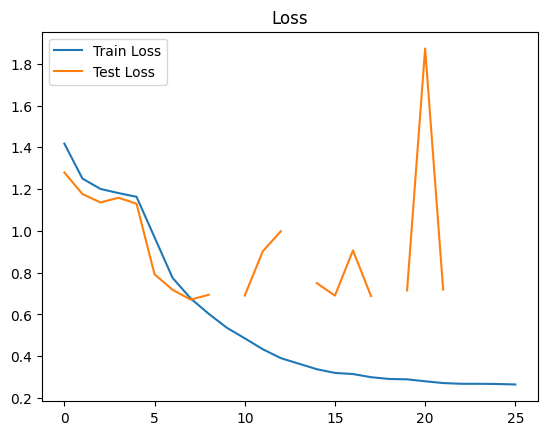

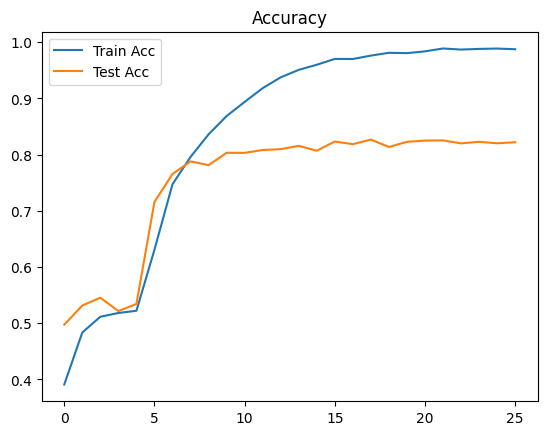

Training Complete.


/tmp/ipykernel_55/1050918930.py:422: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Classification Report:

              precision    recall  f1-score   support

       anger     0.7627    0.7310    0.7465      1253
        fear     0.8094    0.7390    0.7726      1253
       happy     0.9423    0.9130    0.9274      1253
     neutral     0.9086    0.9441    0.9260      1253
         sad     0.7201    0.8069    0.7610      1253

    accuracy                         0.8268      6265
   macro avg     0.8286    0.8268    0.8267      6265
weighted avg     0.8286    0.8268    0.8267      6265


Confusion Matrix:

[[ 916  120    1    6  210]
 [ 140  926    3    3  181]
 [   0    0 1144  107    2]
 [   2    2   66 1183    0]
 [ 143   96    0    3 1011]]


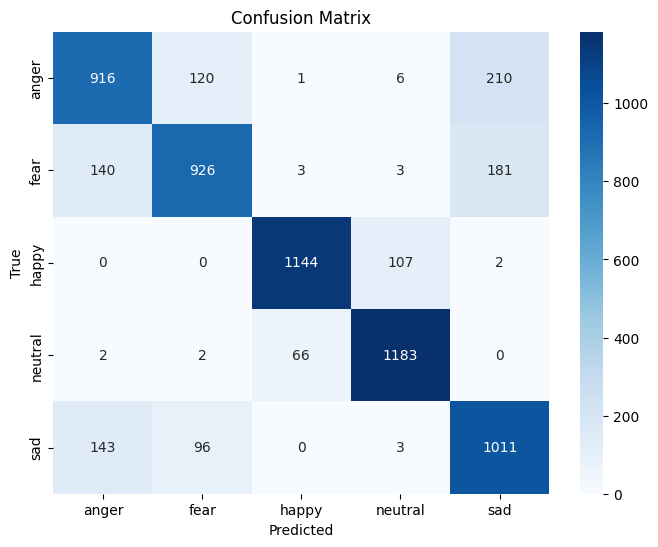

In [2]:
# EfficientNetV2 Emotion Training 
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

import time
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from torch.cuda.amp import autocast, GradScaler
from torchvision import models

# ============================================================
# CONFIG
# ============================================================

train_dir = '/kaggle/input/datasets/lorddemon/face-emotion-balance-dataset-american-asian/Balanced/Train'
test_dir  = '/kaggle/input/datasets/lorddemon/face-emotion-balance-dataset-american-asian/Balanced/Test'

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50

LR = 4e-4
WEIGHT_DECAY = 1e-4

PATIENCE = 8   # early stopping

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

# ============================================================
# FILTER DATASET TO REMOVE SPECIFIC CLASS
# ============================================================

class FilteredImageFolder(datasets.ImageFolder):

    def __init__(self, root, transform=None, exclude_classes=None):

        super().__init__(root, transform=transform)

        if exclude_classes is None:
            exclude_classes = []

        exclude_classes = set(exclude_classes)

        # keep only allowed samples
        new_samples = []
        new_targets = []

        for path, target in self.samples:

            class_name = self.classes[target]

            if class_name not in exclude_classes:

                new_samples.append((path, target))
                new_targets.append(target)

        self.samples = new_samples
        self.targets = new_targets

        # rebuild class_to_idx without excluded classes
        self.classes = [
            c for c in self.classes if c not in exclude_classes
        ]

        self.class_to_idx = {
            c: i for i, c in enumerate(self.classes)
        }

        # remap targets
        remapped_samples = []
        remapped_targets = []

        for path, target in self.samples:

            class_name = os.path.basename(os.path.dirname(path))

            new_target = self.class_to_idx[class_name]

            remapped_samples.append((path, new_target))
            remapped_targets.append(new_target)

        self.samples = remapped_samples
        self.targets = remapped_targets

# ============================================================
# TRANSFORMS (required for EfficientNetV2 pretrained)
# ============================================================

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),
    normalize
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

# ============================================================
# DATASETS
# ============================================================

EXCLUDE_CLASSES = ["disgust", "surprise"]

train_dataset = FilteredImageFolder(
    train_dir,
    transform=train_transform,
    exclude_classes=EXCLUDE_CLASSES
)

test_dataset = FilteredImageFolder(
    test_dir,
    transform=test_transform,
    exclude_classes=EXCLUDE_CLASSES
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# MODEL

weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1

model = efficientnet_v2_s(weights=weights)

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, num_classes)
)

model = model.to(DEVICE)

FREEZE_EPOCHS = 5

def freeze_backbone(model):
    for param in model.features.parameters():
        param.requires_grad = False

def unfreeze_backbone(model):
    for param in model.features.parameters():
        param.requires_grad = True

# Freeze now
freeze_backbone(model)


# LOSS + OPTIMIZER
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# optional scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# AMP scaler
scaler = GradScaler()

# HISTORY TRACKING
history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}


# EARLY STOPPING
best_acc = 0
best_model = copy.deepcopy(model.state_dict())
patience_counter = 0


# TRAIN FUNCTION
def train_one_epoch():

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        _, preds = outputs.max(1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total

    return epoch_loss, epoch_acc


# TEST FUNCTION
def evaluate():

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            with autocast():

                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total

    return epoch_loss, epoch_acc


# TRAIN LOOP
print("\nStarting Training...\n")

for epoch in range(EPOCHS):

    start = time.time()

    # UNFREEZE AFTER FREEZE_EPOCHS
    if epoch == FREEZE_EPOCHS:

        print("\nUnfreezing backbone...")

        unfreeze_backbone(model)

        optimizer = optim.AdamW(
            model.parameters(),
            lr=LR * 0.1,   # lower LR for finetuning
            weight_decay=WEIGHT_DECAY
        )

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=EPOCHS - FREEZE_EPOCHS
        )

    # ========================================================

    train_loss, train_acc = train_one_epoch()

    test_loss, test_acc = evaluate()

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{EPOCHS}")

    if epoch < FREEZE_EPOCHS:
        print("Mode: FROZEN")
    else:
        print("Mode: FINETUNE")

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")
    print(f"Time: {elapsed:.2f}s")

    # Early stopping
    if test_acc > best_acc:

        best_acc = test_acc
        best_model = copy.deepcopy(model.state_dict())

        torch.save(best_model, "best_efficientnetv2_emotion.pth")

        patience_counter = 0

        print("Best model saved")

    else:

        patience_counter += 1

        print(f"EarlyStop Counter: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:

            print("\n Early stopping triggered")
            break

# load best model
model.load_state_dict(best_model)

print("\nBest Test Accuracy:", best_acc)

torch.save(history, "training_history.pth")

# PLOT HISTORY

plt.figure()

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")

plt.legend()
plt.title("Loss")
plt.show()

plt.figure()

plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["test_acc"], label="Test Acc")

plt.legend()
plt.title("Accuracy")
plt.show()

print("Training Complete.")

# FINAL EVALUATION: CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        with autocast():
            outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))

cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:\n")
print(cm)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()